# Глобальный уровень грамотности 2026 год

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Z Аналитик данных ISA/Python/PN_14/literacy_rate_2026.csv')

In [ ]:
df

,Country,Literacy Rate (%),Region,Data Year
0,Ukraine,100.0,Europe Continent,2026
1,Uzbekistan,100.0,Rest Asia,2026
2,North Korea,100.0,Far East,2026
3,Kazakhstan,100.0,Rest Asia,2026
4,Azerbaijan,100.0,Rest Asia,2026
...,...,...,...,...
179,Niger,35.0,Africa Continent,2026
180,South Sudan,35.0,Africa Continent,2026
181,Guinea,32.0,Africa Continent,2026
182,Mali,31.0,Africa Continent,2026


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            184 non-null    object 
 1   Literacy Rate (%)  184 non-null    float64
 2   Region             184 non-null    object 
 3   Data Year          184 non-null    int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 5.9+ KB


In [ ]:
print("\n Пропуски в данных")
print(df.isnull().sum())
print(f"Процент пропусков в Literacy Rate: {(df['Literacy Rate (%)'].isnull().sum() / len(df) * 100):.2f}%")

print("\n Полные дубликаты строк ")
print(f"Найдено дубликатов: {df.duplicated().sum()}")

print("\n Уникальные значения в столбцах ")
print(f"Уникальных стран: {df['Country'].nunique()}")
print(f"Уникальных регионов: {df['Region'].unique()}")
print(f"Года в данных: {sorted(df['Data Year'].unique())}")


 Пропуски в данных
Country              0
Literacy Rate (%)    0
Region               0
Data Year            0
dtype: int64
Процент пропусков в Literacy Rate: 0.00%

 Полные дубликаты строк 
Найдено дубликатов: 0

 Уникальные значения в столбцах 
Уникальных стран: 184
Уникальных регионов: ['Europe Continent' 'Rest Asia' 'Far East' 'Australia Continent'
 'North America Continent' 'South America Continent' 'Middle East'
 'Subcontinent' 'Africa Continent']
Года в данных: [np.int64(2026)]


In [ ]:
# 1. Приведение типов данных (гарантия корректной работы функций)
df['Literacy Rate (%)'] = pd.to_numeric(df['Literacy Rate (%)'], errors='coerce')
df['Data Year'] = df['Data Year'].astype(int)
df['Country'] = df['Country'].astype(str).str.strip()  # убираем пробелы по краям
df['Region'] = df['Region'].astype(str).str.strip()

# 2. Валидация диапазона значений - защита от аномалий
# Грамотность не может быть <0% или >100%
df = df[(df['Literacy Rate (%)'] >= 0) & (df['Literacy Rate (%)'] <= 100)]
print(f" Строк после валидации: {len(df)}")

# 3. Стандартизация названий регионов - удобно для графиков
# Убираем суффикс " Continent" для краткости
df['Region'] = df['Region'].str.replace(' Continent', '', regex=False)
print(f" Уникальные регионы: {df['Region'].unique()}")

 Строк после валидации: 184
 Уникальные регионы: ['Europe' 'Rest Asia' 'Far East' 'Australia' 'North America'
 'South America' 'Middle East' 'Subcontinent' 'Africa']


Приведение данных  к стилю Сamel-Case

In [ ]:
# Словарь соответствия: 'Старое имя': 'Новое имя'
columns_mapping = {
    'Country': 'country',
    'Literacy Rate (%)': 'literacyRate',
    'Region': 'region',
    'Data Year': 'dataYear'
}

# Применяем переименование
df.rename(columns=columns_mapping, inplace=True)

# Проверяем результат
print(" Новые названия столбцов:")
print(df.columns.tolist())
print("\n Информация о датафрейме:")
df.info()

 Новые названия столбцов:
['country', 'literacyRate', 'region', 'dataYear']

 Информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country       184 non-null    object 
 1   literacyRate  184 non-null    float64
 2   region        184 non-null    object 
 3   dataYear      184 non-null    int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 5.9+ KB


**Исследование**

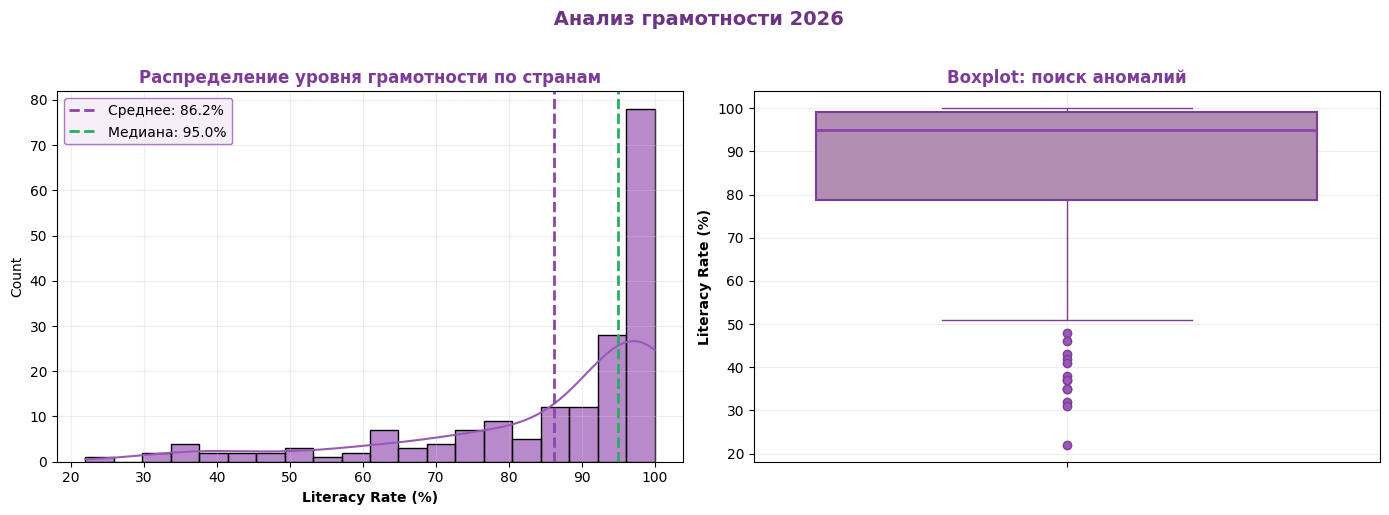

Глобальная статистика по грамотности (2026) ===
count    184.00
mean      86.22
std       18.26
min       22.00
25%       78.75
50%       95.00
75%       99.00
max      100.00
Name: literacyRate, dtype: float64

 Средний уровень грамотности в мире: 86.22%
 Медиана: 95.00%
 Стандартное отклонение: 18.26%


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Настройка палитры сиреневых оттенков
lilac_palette = ['#E6E6FA', '#D8BFD8', '#C8A2C8', '#B888B8', '#A86EA8', '#9B59B6', '#8E44AD', '#7D3C98']
sns.set_palette(lilac_palette)
plt.rcParams['figure.figsize'] = [12, 6]

# Распределение - создаём фигуру с двумя графиками
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма + KDE (кривая плотности)
sns.histplot(data=df, x='literacyRate', bins=20, kde=True,
             color='#9B59B6', alpha=0.7, ax=axes[0])
axes[0].axvline(df['literacyRate'].mean(), color='#8E44AD', linestyle='--',
                linewidth=2, label=f'Среднее: {df["literacyRate"].mean():.1f}%')
axes[0].axvline(df['literacyRate'].median(), color='#27AE60', linestyle='--',
                linewidth=2, label=f'Медиана: {df["literacyRate"].median():.1f}%')
axes[0].set_title('Распределение уровня грамотности по странам',
                  fontsize=12, fontweight='bold', color='#7D3C98')
axes[0].set_xlabel('Literacy Rate (%)', fontweight='semibold')
axes[0].legend(facecolor='#F4ECF7', edgecolor='#9B59B6')
axes[0].grid(True, alpha=0.3, color='#D8BFD8')

# Boxplot для выявления выбросов
sns.boxplot(data=df, y='literacyRate', color='#B888B8',
            boxprops=dict(edgecolor='#7D3C98', linewidth=1.5),
            medianprops=dict(color='#8E44AD', linewidth=2),
            whiskerprops=dict(color='#7D3C98'),
            capprops=dict(color='#7D3C98'),
            flierprops=dict(marker='o', markerfacecolor='#9B59B6',
                           markersize=6, markeredgecolor='#7D3C98'),
            ax=axes[1])
axes[1].set_title('Boxplot: поиск аномалий',
                  fontsize=12, fontweight='bold', color='#7D3C98')
axes[1].set_ylabel('Literacy Rate (%)', fontweight='semibold')
axes[1].grid(True, alpha=0.3, color='#D8BFD8')

plt.suptitle(' Анализ грамотности 2026', fontsize=14, fontweight='bold',
             color='#6C3483', y=1.02)
plt.tight_layout()
plt.show()


print("Глобальная статистика по грамотности (2026) ===")
print(df['literacyRate'].describe().round(2))

print(f"\n Средний уровень грамотности в мире: {df['literacyRate'].mean():.2f}%")
print(f" Медиана: {df['literacyRate'].median():.2f}%")
print(f" Стандартное отклонение: {df['literacyRate'].std():.2f}%")

Мы видим страны с почти всеобщей грамотностью (95-100%) и страны с серьёзными проблемами в образовании (<70%). Разница между средним и медианой указывает на влияние стран с очень низкой грамотностью.
Визуализация Boxplot показавает около 15-20 стран с критически низким уровнем грамотности, стран-аутсайдеров с показателями(ниже 50%). В большинстве стран (пик на 95-100%) имеется высокий уровень грамотности.

=== 📊 Статистика по регионам ===
                mean  median    std  count
region                                    
Europe         99.19   100.0   1.26     36
Far East       98.57    99.0   1.13      7
South America  94.42    94.0   3.12     12
Australia      93.00    97.5  11.56     12
North America  91.86    95.5  10.38     22
Rest Asia      91.45    96.5  15.20     20
Middle East    91.03    95.0   9.14     16
Subcontinent   75.57    74.0  14.44      7
Africa         67.67    74.5  20.50     52


/tmp/ipython-input-757463751.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='literacyRate', palette='Set2')


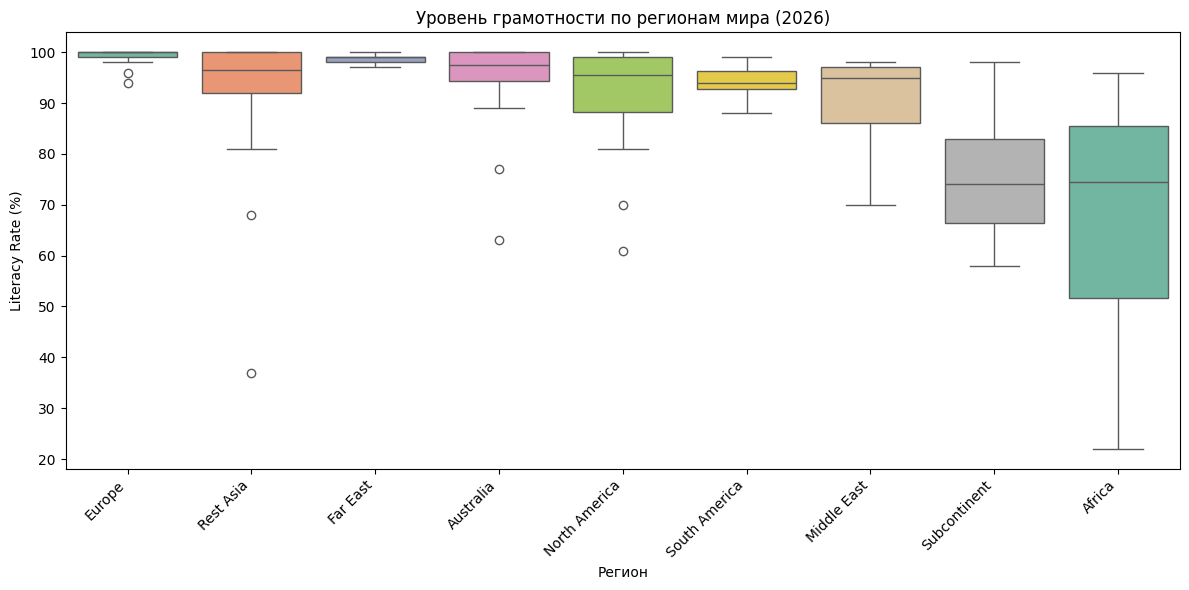

/tmp/ipython-input-757463751.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_means.values, y=region_means.index, palette='viridis')


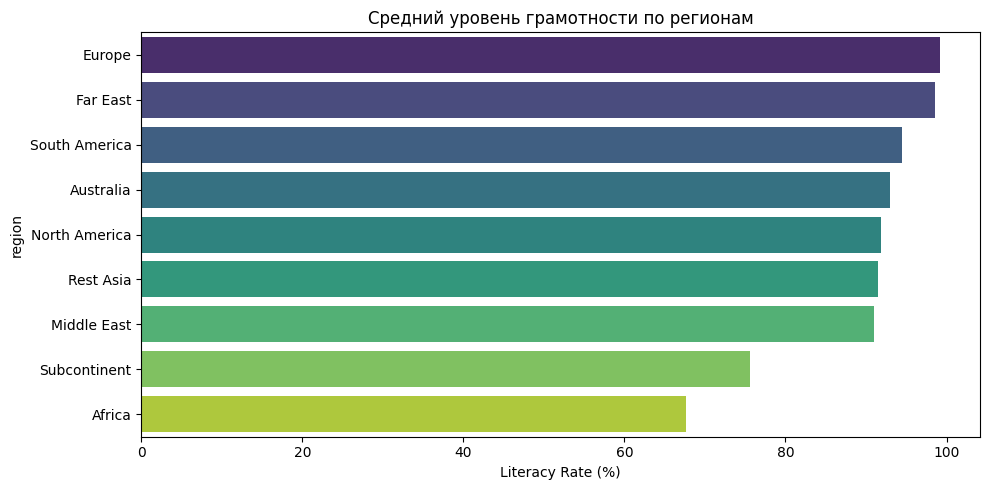

In [ ]:
# Статистика по регионам
region_stats = df.groupby('region')['literacyRate'].agg(['mean', 'median', 'std', 'count']).round(2)
region_stats = region_stats.sort_values('mean', ascending=False)
print("=== Статистика по регионам ===")
print(region_stats)

# Визуализация: Boxplot по регионам
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='region', y='literacyRate', palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Уровень грамотности по регионам мира (2026)')
plt.ylabel('Literacy Rate (%)')
plt.xlabel('Регион')
plt.tight_layout()
plt.show()

# Bar chart: средние значения по регионам
plt.figure(figsize=(10, 5))
region_means = df.groupby('region')['literacyRate'].mean().sort_values(ascending=False)
sns.barplot(x=region_means.values, y=region_means.index, palette='viridis')
plt.title('Средний уровень грамотности по регионам')
plt.xlabel('Literacy Rate (%)')
plt.tight_layout()
plt.show()

Статистика по регионам
                mean  median    std  count
region                                    
Europe         99.19   100.0   1.26     36
Far East       98.57    99.0   1.13      7
South America  94.42    94.0   3.12     12
Australia      93.00    97.5  11.56     12
North America  91.86    95.5  10.38     22
Rest Asia      91.45    96.5  15.20     20
Middle East    91.03    95.0   9.14     16
Subcontinent   75.57    74.0  14.44      7
Africa         67.67    74.5  20.50     52


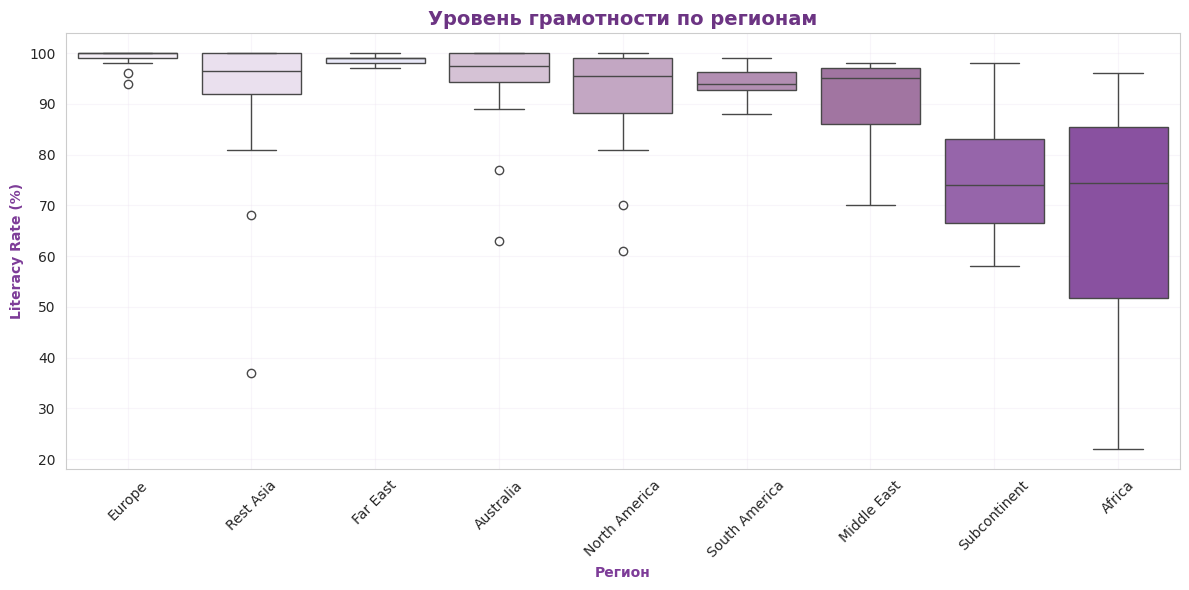

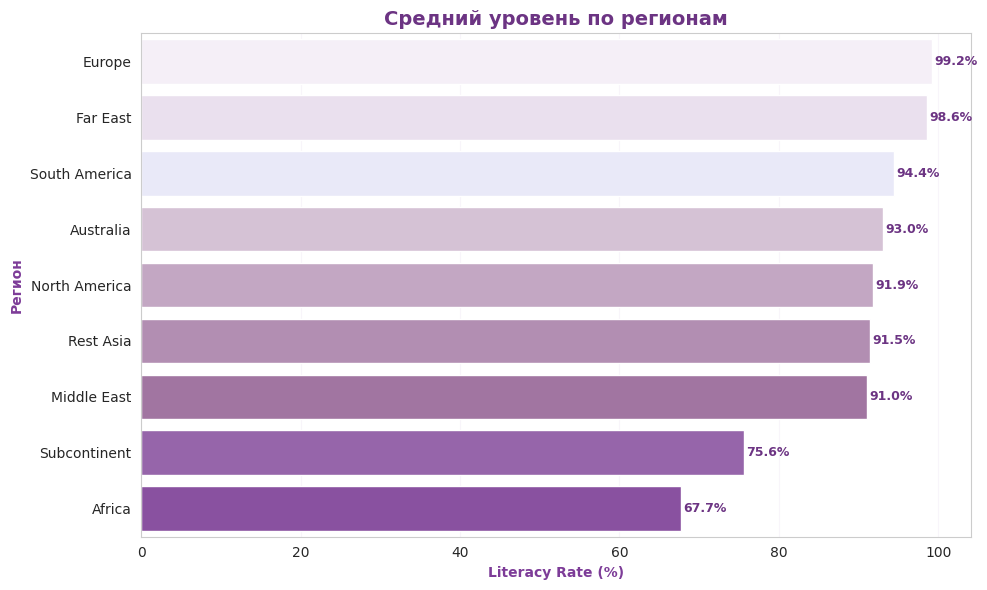

In [ ]:
# Статистика по регионам
region_stats = df.groupby('region')['literacyRate'].agg(['mean', 'median', 'std', 'count']).round(2)
region_stats = region_stats.sort_values('mean', ascending=False)
print("Статистика по регионам")
print(region_stats)

# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [14, 6]
plt.rcParams['font.size'] = 10

# Расширение палитры до 9+ цветов
lilac_palette = [
    '#F5EEF8',  # Очень светлый
    '#EBDEF0',  # Светло-лавандовый
    '#E6E6FA',  # Lavender
    '#D8BFD8',  # Thistle
    '#C8A2C8',  # Светло-сиреневый
    '#B888B8',  # Сиреневый
    '#A86EA8',  # Насыщенный
    '#9B59B6',  # Purple
    '#8E44AD',  # Тёмно-фиолетовый
    '#7D3C98',  # Глубокий
    '#6C3483'   # Очень тёмный
]

# Boxplot по регионам (исправленный)
plt.figure(figsize=(12, 6))

# Создаём boxplot с hue для корректной работы палитры
ax1 = sns.boxplot(data=df, x='region', y='literacyRate',
                  hue='region',  # Добавляем hue
                  palette=lilac_palette[:len(df['region'].unique())],
                  legend=False)  # Убираем легенду

ax1.set_title('Уровень грамотности по регионам',
              fontsize=14, fontweight='bold', color='#6C3483')
ax1.set_xlabel('Регион', fontweight='semibold', color='#7D3C98')
ax1.set_ylabel('Literacy Rate (%)', fontweight='semibold', color='#7D3C98')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, color='#EBDEF0')

plt.tight_layout()
plt.show()

# Bar chart средних значений
plt.figure(figsize=(10, 6))

region_means = df.groupby('region')['literacyRate'].mean().sort_values(ascending=False)
n_regions = len(region_means)

# Создаём barplot с hue
ax2 = sns.barplot(x=region_means.values, y=region_means.index,
                  hue=region_means.index,  # Добавляем hue
                  palette=lilac_palette[:n_regions],
                  legend=False)  # Убираем легенду

ax2.set_title('Средний уровень по регионам',
              fontsize=14, fontweight='bold', color='#6C3483')
ax2.set_xlabel('Literacy Rate (%)', fontweight='semibold', color='#7D3C98')
ax2.set_ylabel('Регион', fontweight='semibold', color='#7D3C98')
ax2.grid(True, alpha=0.3, axis='x', color='#EBDEF0')

# Подписи значений
for i, v in enumerate(region_means.values):
    ax2.text(v + 0.3, i, f'{v:.1f}%',
            color='#6C3483', fontweight='bold',
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

Выражена четкая региональная поляризация: Европа (99.2%) и Дальний Восток (98.6%) достигли практически всеобщей грамотности с минимальным разбросом, в то время как Африка (67.7%) и Субконтинент (75.6%) критически отстают.
Африка с огромным разбросом показателей (от 22% до 96%) говорит о глубоком внутреннем разрыве между успешными странами и государствами с катастрофически низким уровнем образования.


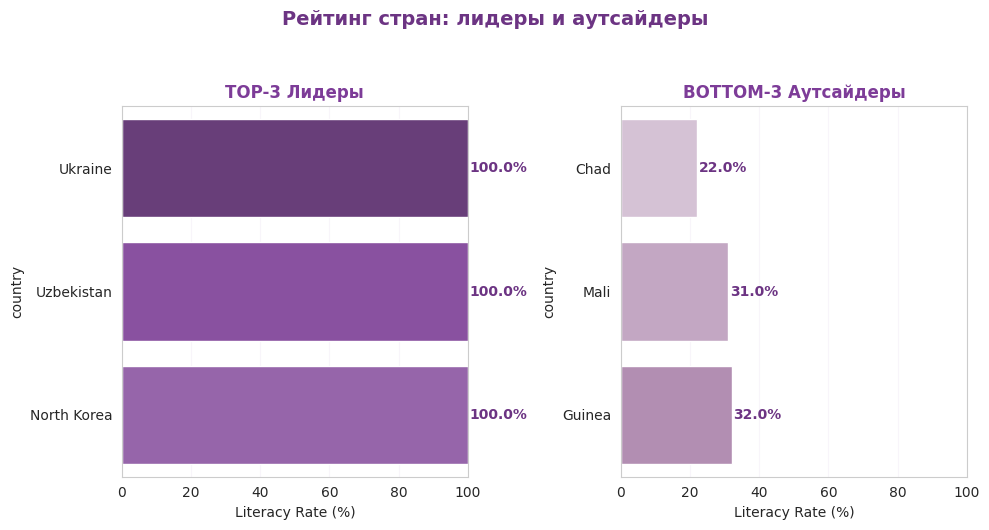

 TOP-3 и BOTTOM-3 страны 

TOP-3 ЛИДЕРЫ:
   1. Ukraine — 100.0% (Europe)
   2. Uzbekistan — 100.0% (Rest Asia)
   3. North Korea — 100.0% (Far East)

BOTTOM-3 АУТСАЙДЕРЫ:
   184. Chad — 22.0% (Africa)
   183. Mali — 31.0% (Africa)
   182. Guinea — 32.0% (Africa)

Разрыв между лидером и аутсайдером: 78.0 п.п.


In [ ]:
# Топ-3 и Bottom-3 страны
top_3 = df.nlargest(3, 'literacyRate')[['country', 'literacyRate', 'region']]
bottom_3 = df.nsmallest(3, 'literacyRate')[['country', 'literacyRate', 'region']]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Сиреневая палитра для Top-3
top_palette = ['#6C3483','#8E44AD','#9B59B6']

# Top-3 (наибольший уровень грамотности)
sns.barplot(data=top_3, x='literacyRate', y='country',
            hue='country',
            palette=top_palette,
            legend=False,
            ax=axes[0])
axes[0].set_title('TOP-3 Лидеры',
                  fontweight='bold', color='#7D3C98', fontsize=12)
axes[0].set_xlabel('Literacy Rate (%)')
axes[0].set_xlim(0, 100)
axes[0].grid(True, alpha=0.3, axis='x', color='#EBDEF0')

# Добавляем значения на бары
for i, v in enumerate(top_3['literacyRate'].values):
    axes[0].text(v + 0.5, i, f'{v:.1f}%',
                color='#6C3483', fontweight='bold',
                va='center', fontsize=10)

# Палитра для Bottom-3
bottom_palette = ['#D8BFD8', '#C8A2C8', '#B888B8']

# Bottom-3 (наименьший уровень грамотности)
sns.barplot(data=bottom_3, x='literacyRate', y='country',
            hue='country',
            palette=bottom_palette,
            legend=False,
            ax=axes[1])
axes[1].set_title('BOTTOM-3 Аутсайдеры',
                  fontweight='bold', color='#7D3C98', fontsize=12)
axes[1].set_xlabel('Literacy Rate (%)')
axes[1].set_xlim(0, 100)
axes[1].grid(True, alpha=0.3, axis='x', color='#EBDEF0')

# Добавляем значения на бары
for i, v in enumerate(bottom_3['literacyRate'].values):
    axes[1].text(v + 0.5, i, f'{v:.1f}%',
                color='#6C3483', fontweight='bold',
                va='center', fontsize=10)

plt.suptitle('Рейтинг стран: лидеры и аутсайдеры',
             fontsize=14, fontweight='bold', color='#6C3483', y=1.05)
plt.tight_layout()
plt.show()

# Вывод статистики
print(" TOP-3 и BOTTOM-3 страны \n")
print("TOP-3 ЛИДЕРЫ:")
for i, row in top_3.iterrows():
    print(f"   {i+1}. {row['country']} — {row['literacyRate']:.1f}% ({row['region']})")

print("\nBOTTOM-3 АУТСАЙДЕРЫ:")
for i, row in bottom_3.iterrows():
    print(f"   {i+1}. {row['country']} — {row['literacyRate']:.1f}% ({row['region']})")

print(f"\nРазрыв между лидером и аутсайдером: {top_3['literacyRate'].max() - bottom_3['literacyRate'].min():.1f} п.п.")

Достижения и возможности лидеров достигли показателя в 100% грамотности — Украина, Узбекистан и Северная Корея.
В то же время, африканские страны — Чад (22%), Мали (31%) и Гвинея (32%) — сталкиваются с катастрофической ситуацией, где более двух третей населения остаются неграмотными. Разрыв в 78 процентных пунктов между лидерами и аутсайдерами отражает критическое неравенство в доступе к образованию в мировом масштабе.


In [ ]:
# Интерактивная карта мира
fig_map2 = px.choropleth(
    df,
    locations='country',
    locationmode='country names',
    color='literacyRate',
    hover_name='country',
    hover_data={'region': True, 'literacyRate': ':.2f'},
    color_continuous_scale=[
        '#E74C3C',  # Красный (0-30%) - критический
        '#E67E22',  # Оранжевый (30-50%) - низкий
        '#F1C40F',  # Жёлтый (50-65%) - средний
        '#2ECC71',  # Зелёный (65-80%) - хороший
        '#27AE60',  # Тёмно-зелёный (80-90%) - высокий
        '#2980B9',  # Синий (90-97%) - очень высокий
        '#8E44AD',  # Фиолетовый (97-100%) - отличный
    ],
    range_color=[0, 100],
    title='Глобальный уровень грамотности (2026)'
)

fig_map2.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='#2C3E50',
        coastlinewidth=1,
        showcountries=True,
        countrycolor='#FFFFFF',
        countrywidth=0.5
    ),
    font=dict(
        family='Arial',
        size=11,
        color='#2C3E50'
    )
)

fig_map2.show()

In [ ]:
# Автоматическая генерация ключевых выводов
print("\n Ключевые инсайты ")

# 1. Разрыв между лидером и аутсайдером
gap = df['literacyRate'].max() - df['literacyRate'].min()
print(f" Глобальный разрыв: {gap:.1f} п.п. (от {df['literacyRate'].min():.1f}% до {df['literacyRate'].max():.1f}%)")

# 2. Регион-лидер и регион-аутсайдер
best_region = region_stats['mean'].idxmax()
worst_region = region_stats['mean'].idxmin()
print(f" Лучший регион: {best_region} ({region_stats.loc[best_region, 'mean']}%)")
print(f" Самый сложный регион: {worst_region} ({region_stats.loc[worst_region, 'mean']}%)")

# 3. Сколько стран выше/ниже мирового среднего
above_avg = (df['literacyRate'] >= df['literacyRate'].mean()).sum()
print(f" Стран выше среднего: {above_avg} из {len(df)} ({above_avg/len(df)*100:.1f}%)")

# 4. Коэффициент вариации (относительная изменчивость)
cv = df['literacyRate'].std() / df['literacyRate'].mean() * 100
print(f" Коэффициент вариации: {cv:.1f}% — {'высокая неоднородность' if cv > 20 else 'умеренная неоднородность'}")


 Ключевые инсайты 
 Глобальный разрыв: 78.0 п.п. (от 22.0% до 100.0%)
 Лучший регион: Europe (99.19%)
 Самый сложный регион: Africa (67.67%)
 Стран выше среднего: 125 из 184 (67.9%)
 Коэффициент вариации: 21.2% — высокая неоднородность


Карта наглядно демонстрирует чёткое разделение мира: развитые регионы (Европа, Северная Америка, Дальний Восток, Австралия) 90-100% грамотности, в то время как экваториальная Африка выделяется красными и оранжевыми оттенками (20-50%), что указывает на критический образовательный кризис.
Таким образом Африканский континент представляет собой сплошную зону образовательной отсталости с единичными исключениями, тогда как Европа и развитые азиатские страны обеспечили практически всеобщую грамотность. Разрыв между регионами достигает 30-70 процентных пунктов, что свидетельствует о системном глобальном неравенстве.

# ИТОГОВЫЙ ОТЧЁТ ПО ИССЛЕДОВАНИЮ
Глобальный уровень грамотности (2026)


ВЫВОДЫ
1. Мировой уровень грамотности в 2026 году составляет 86.2% (медиана 95.0%), но за усреднённым показателем скрывается глубокая глобальная поляризация: 184 проанализированные страны демонстрируют разброс от 22% до 100%.
2. Региональное неравенство показывает что лидеры образования Европа (99.2%) и Дальний Восток (98.6%) достигли практически всеобщей грамотности с минимальным внутренним разбросом.
Эти регионы демонстрируют устойчивые образовательные системы с охватом близким к 100%. В то время как Африка (67.7%) является единственным континентом с катастрофически низким уровнем грамотности, а Субконтинент (75.6%) (Южная Азия) показывает второй уровень по отставанию.Разрыв между лидером и аутсайдером составляет 31.5 п.п. на региональном уровне.
3. Страновая дифференциация показывает достижения
 3-х стран, которые достигли 100% в грамотности - это Украина, Узбекистан, Северная Корея.
Кризисные ситуации в странах расположеных в Сахарской Африке и это:
 Чад (22%) — самый низкий показатель в мире, более 3/4 населения неграмотны
Мали (31%) и Гвинея (32%) — аналогичная критическая ситуация
Глобальный разрыв между лидером (100%) и аутсайдером (22%) достигает 78 процентных пунктов  — это критическое неравенство в доступе к базовому праву на образование.
4. Структурных закономерностях выявленна географическая детерминированность и внутрирегиональная вариативность.
Развитые регионы (Европа, Северная Америка, Дальний Восток, Австралия) образуют единое пространство высокой грамотности (90-100%)
Экваториальная Африка представляет собой сплошную зону образовательного кризиса (20-60%)
Наблюдается чёткая широтная градация: чем ближе к экватору (в развивающихся регионах), тем ниже показатели.
Внутрирегиональная вариативность в Африке демонстрирует наибольший разброс (от 22% до ~96%) и указывает на значительные внутренние различия между странами.В Европе показатель вариативности минимален  — все страны находятся на высоком уровне.
ИТОГ:
Мир в 2026 году остаётся глубоко разделённым в сфере образования. Пока развитые страны обеспечили всеобщую грамотность и переходят к задачам повышения качества образования, значительная часть человечества (преимущественно в Африке) лишена базового права на грамотность.